# Assignment 8: Clustering 
##### Author: Md Ashhar Farooqui
##### Date: 19-07-2025

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [44]:
df = pd.read_csv("EastWestAirlines1.csv")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


# Data Preprocessing:
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.


In [45]:
# 1. Check for missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [46]:
# 2. Drop ID# column as it's not useful for clustering
df1 = df.drop(columns=['ID#'])

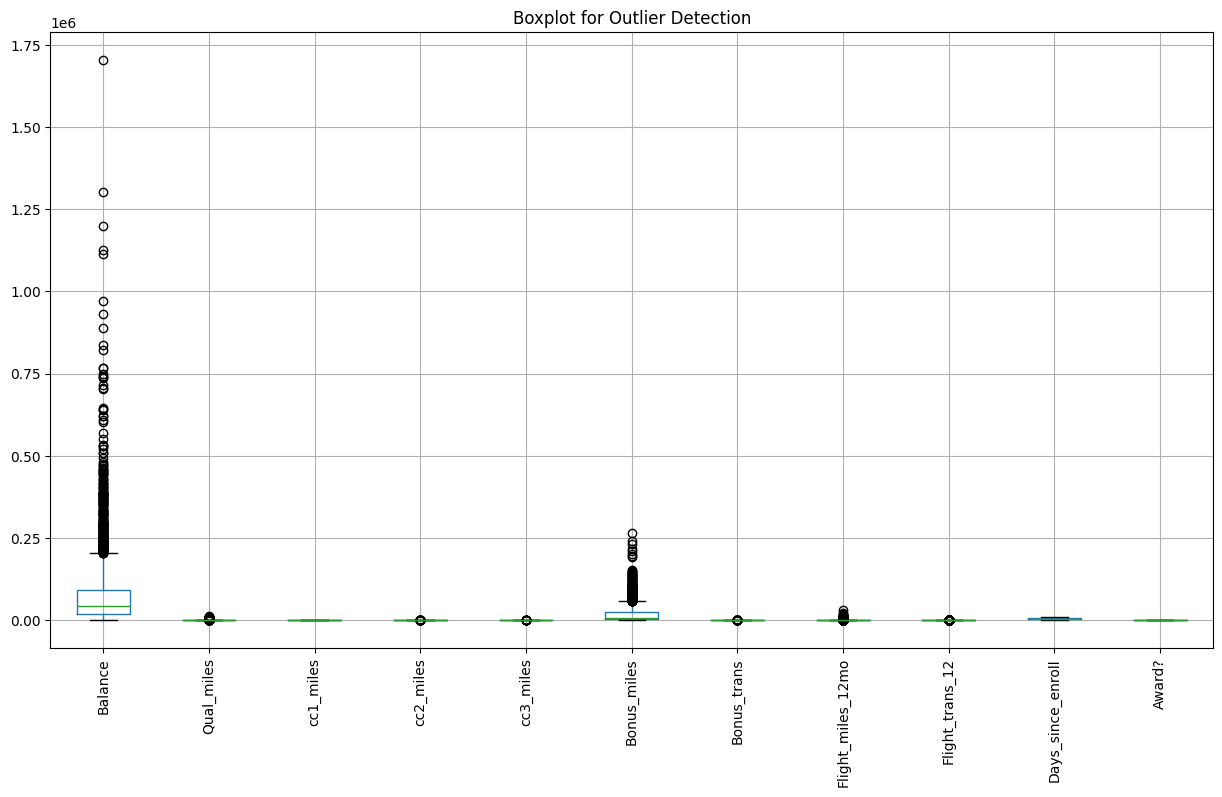

In [47]:
# 3. Check for outliers using boxplots
plt.figure(figsize=(15, 8))
df1.boxplot(rot=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [48]:
# 4. Remove outliers using IQR method
def remove_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    return data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

df_no_outliers = remove_outliers_iqr(df1)
df_no_outliers = df_no_outliers.reset_index(drop=True)  # Reset index

print(f"Original shape: {df1.shape}, After outlier removal: {df_no_outliers.shape}")

Original shape: (3999, 11), After outlier removal: (2875, 11)


In [49]:
# 5. Feature scaling (Standardization)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_no_outliers)

# Convert back to DataFrame for easier handling
df_scaled = pd.DataFrame(scaled_data, columns=df_no_outliers.columns)
df_scaled = df_scaled.reset_index(drop=True)  # Reset index

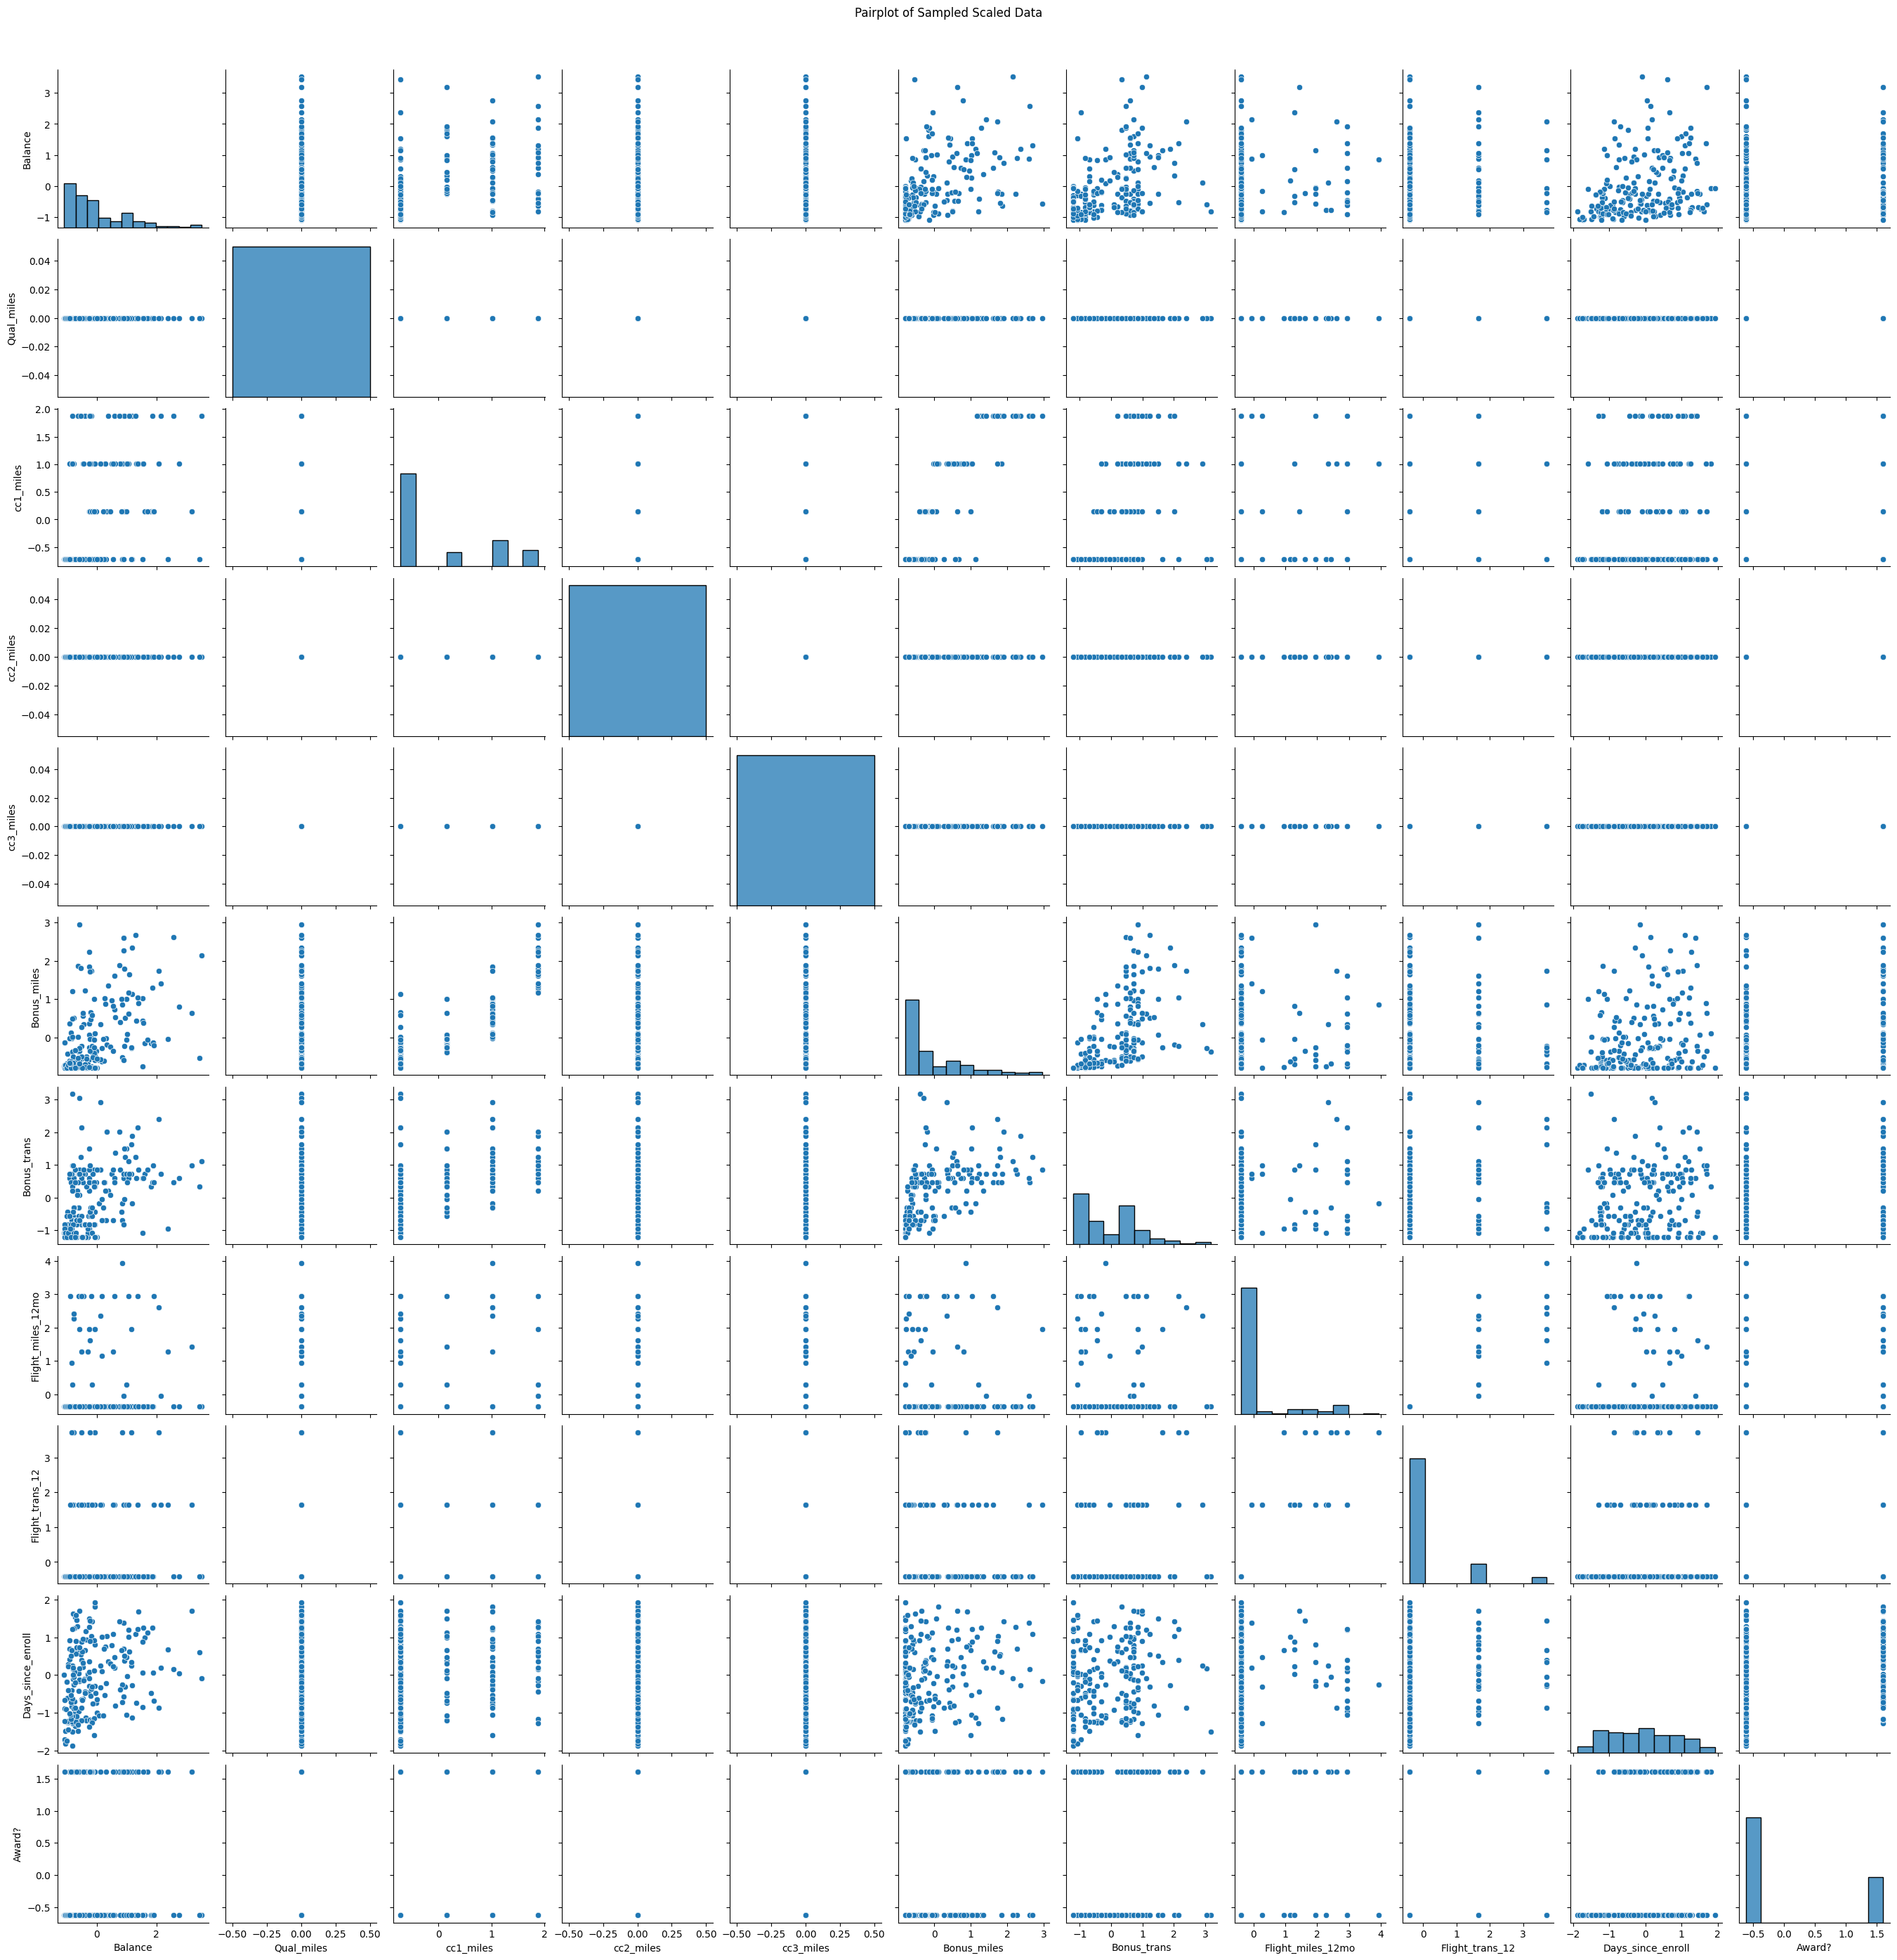

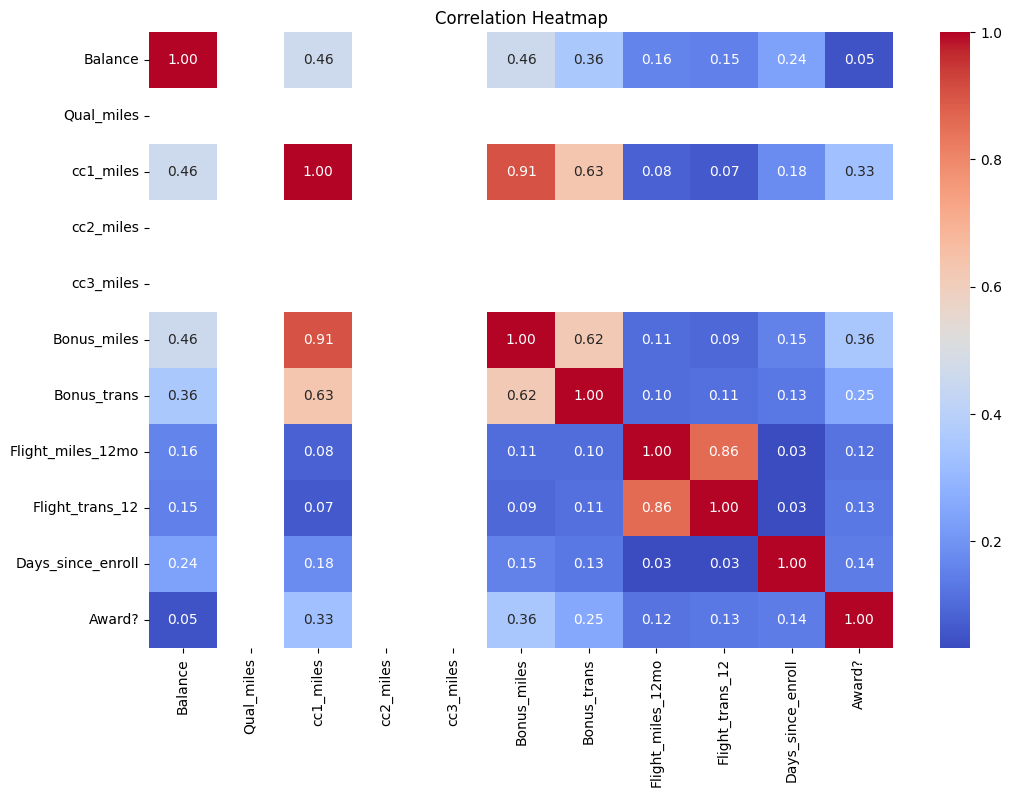

In [50]:
# 6. Quick EDA: Pairplot and correlation heatmap
sns.pairplot(df_scaled.sample(200))  # sample for speed
plt.suptitle("Pairplot of Sampled Scaled Data", y=1.02)
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df_scaled.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Implementing Clustering Algorithms

* ### K-Means Clustering Implementation

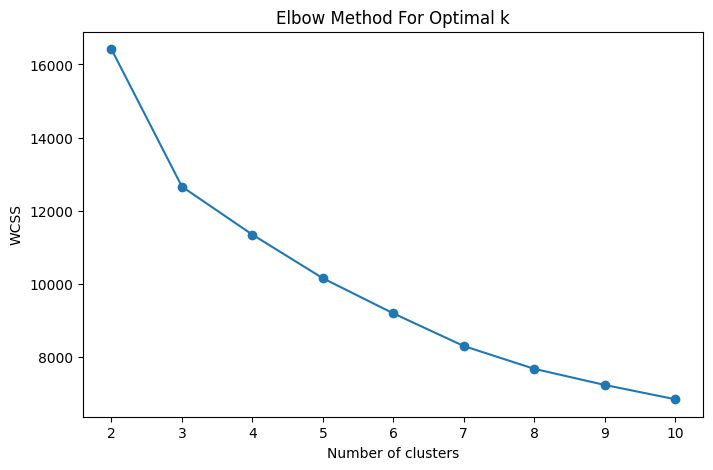

In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Find optimal number of clusters using Elbow Method
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [52]:
# 2. Fit KMeans with optimal k (choose k based on elbow plot, e.g., k=4)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled)

In [53]:
# 3. Add cluster labels to the DataFrame
df_scaled['KMeans_Cluster'] = labels

In [54]:
# 4. Silhouette Score
score = silhouette_score(df_scaled.drop('KMeans_Cluster', axis=1), labels)
print(f'Silhouette Score for KMeans (k={k}): {score:.3f}')

Silhouette Score for KMeans (k=4): 0.321


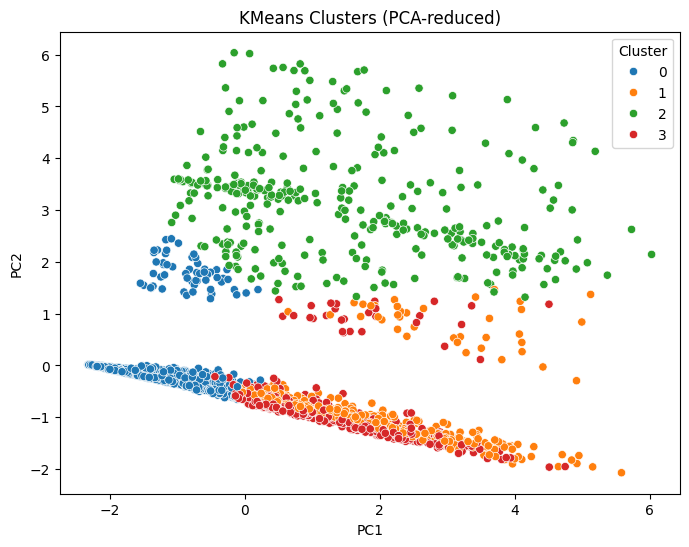

In [55]:
# 5. Visualize clusters using first two principal components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled.drop('KMeans_Cluster', axis=1))

plt.figure(figsize=(8,6))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=labels, palette='tab10')
plt.title('KMeans Clusters (PCA-reduced)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

* ### Hierarchical Clustering Implementation

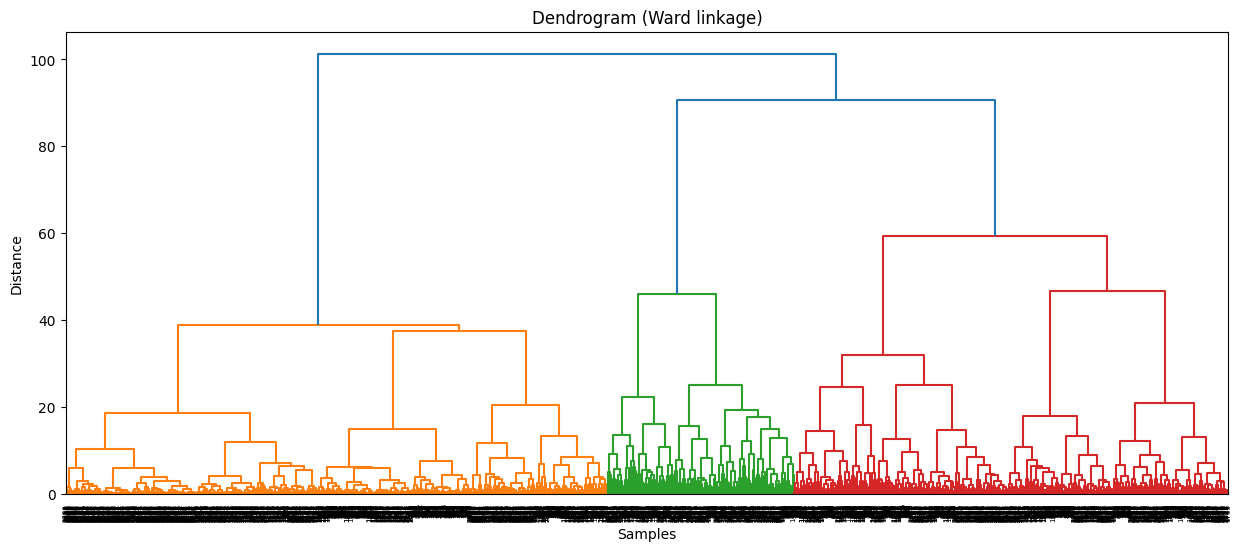

In [56]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

# 1. Create linkage matrix and plot dendrogram
plt.figure(figsize=(15, 6))
Z = linkage(df_scaled.drop('KMeans_Cluster', axis=1), method='ward')
dendrogram(Z)
plt.title('Dendrogram (Ward linkage)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [57]:
# 2. Fit Agglomerative Clustering with optimal clusters (e.g., 4)
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(df_scaled.drop('KMeans_Cluster', axis=1))

In [58]:
# 3. Add cluster labels to DataFrame
df_scaled['Hierarchical_Cluster'] = hc_labels

In [59]:
# 4. Silhouette Score
hc_score = silhouette_score(df_scaled.drop(['KMeans_Cluster', 'Hierarchical_Cluster'], axis=1), hc_labels)
print(f'Silhouette Score for Hierarchical Clustering: {hc_score:.3f}')

Silhouette Score for Hierarchical Clustering: 0.302


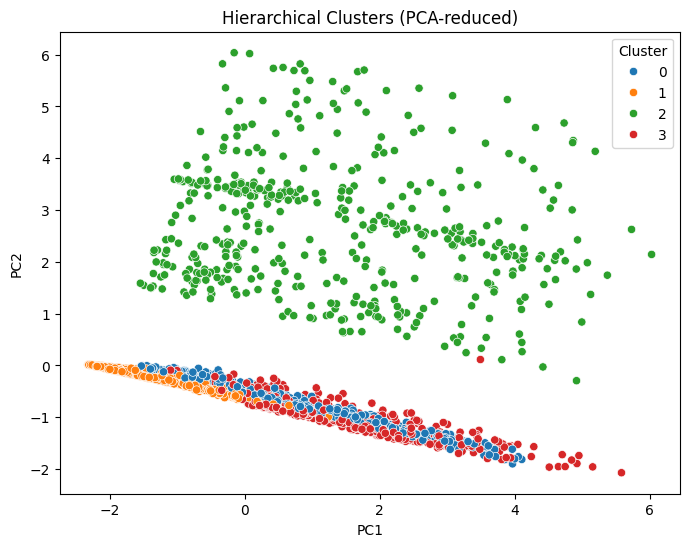

In [60]:
# 5. Visualize clusters using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled.drop(['KMeans_Cluster', 'Hierarchical_Cluster'], axis=1))

plt.figure(figsize=(8,6))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=hc_labels, palette='tab10')
plt.title('Hierarchical Clusters (PCA-reduced)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

* ### DBSCAN Clustering Implementation

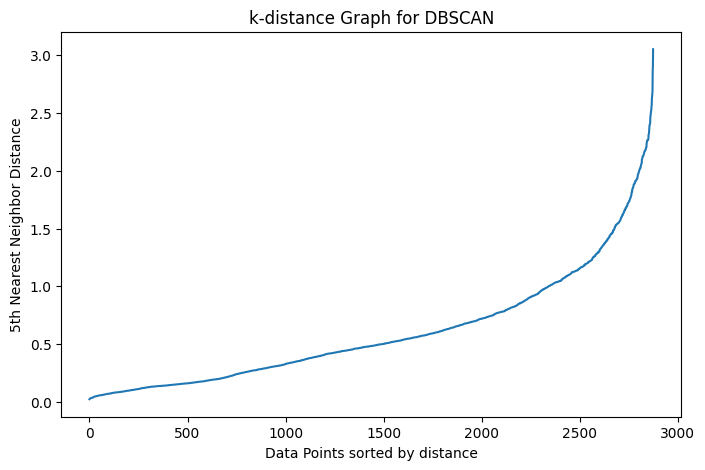

In [61]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 1. Find a good value for eps using k-distance plot (k = min_samples)
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_scaled.drop(['KMeans_Cluster', 'Hierarchical_Cluster'], axis=1))
distances, indices = neighbors_fit.kneighbors(df_scaled.drop(['KMeans_Cluster', 'Hierarchical_Cluster'], axis=1))
distances = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title('k-distance Graph for DBSCAN')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.show()

In [62]:
# 2. Fit DBSCAN (choose eps from the plot, e.g., eps=1.5)
dbscan = DBSCAN(eps=1.5, min_samples=min_samples)
db_labels = dbscan.fit_predict(df_scaled.drop(['KMeans_Cluster', 'Hierarchical_Cluster'], axis=1))

In [63]:
# 3. Add cluster labels to DataFrame
df_scaled['DBSCAN_Cluster'] = db_labels

In [64]:
# 4. Silhouette Score (only if more than 1 cluster and not all noise)
if len(set(db_labels)) > 1 and len(set(db_labels)) != 1 + (1 if -1 in db_labels else 0):
    db_score = silhouette_score(df_scaled.drop(['KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster'], axis=1), db_labels)
    print(f'Silhouette Score for DBSCAN: {db_score:.3f}')
else:
    print('Silhouette Score for DBSCAN: Not applicable (only one cluster or all noise)')

Silhouette Score for DBSCAN: 0.249


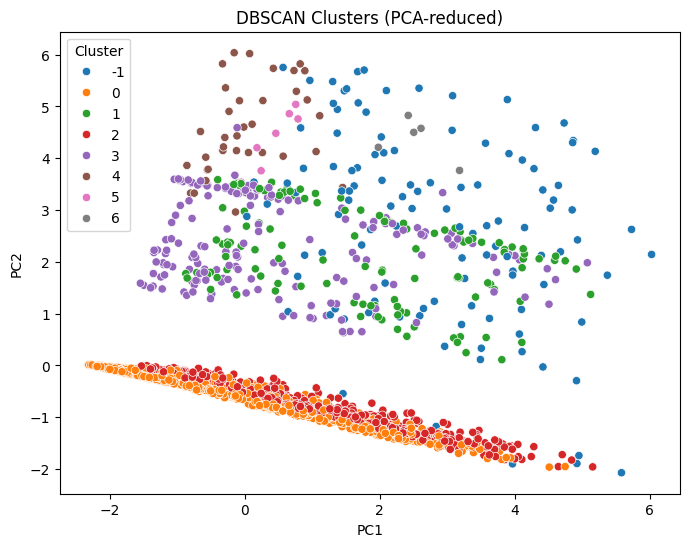

In [65]:
# 5. Visualize clusters using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled.drop(['KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster'], axis=1))

plt.figure(figsize=(8,6))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=db_labels, palette='tab10', legend='full')
plt.title('DBSCAN Clusters (PCA-reduced)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

## Cluster Analysis and Interpretation

In [66]:
# K-Means Cluster Analysis
print("K-Means Cluster Counts:")
print(df_scaled['KMeans_Cluster'].value_counts())
print("\nK-Means Cluster Means:")
print(df_no_outliers.groupby(df_scaled['KMeans_Cluster']).mean())

K-Means Cluster Counts:
KMeans_Cluster
0    1543
3     539
1     453
2     340
Name: count, dtype: int64

K-Means Cluster Means:
                     Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                              
0               26357.586520         0.0   1.042126        1.0        1.0   
1               53761.516556         0.0   3.130243        1.0        1.0   
2               64862.867647         0.0   2.000000        1.0        1.0   
3               88290.831169         0.0   2.884972        1.0        1.0   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                  
0                2289.062216     4.773817           4.451717         0.036293   
1               25830.536424    15.997792          12.152318         0.083885   
2               13874.029412    11.423529         436.758824         1.320588   
3  

In [67]:
# Hierarchical Cluster Analysis
print("\nHierarchical Cluster Counts:")
print(df_scaled['Hierarchical_Cluster'].value_counts())
print("\nHierarchical Cluster Means:")
print(df_no_outliers.groupby(df_scaled['Hierarchical_Cluster']).mean())


Hierarchical Cluster Counts:
Hierarchical_Cluster
1    1341
0     546
3     527
2     461
Name: count, dtype: int64

Hierarchical Cluster Means:
                           Balance  Qual_miles  cc1_miles  cc2_miles  \
Hierarchical_Cluster                                                   
0                     36238.271062         0.0   2.391941        1.0   
1                     25586.347502         0.0   1.082774        1.0   
2                     61753.466377         0.0   2.041215        1.0   
3                     98861.707780         0.0   2.963947        1.0   

                      cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
Hierarchical_Cluster                                                            
0                           1.0  17373.097070    12.040293           0.000000   
1                           1.0   2449.995526     5.545116           0.000000   
2                           1.0  14252.574837    11.407809         355.900217   
3               

In [68]:
# DBSCAN Cluster Analysis
print("\nDBSCAN Cluster Counts:")
print(df_scaled['DBSCAN_Cluster'].value_counts())
print("\nDBSCAN Cluster Means (excluding noise):")


DBSCAN Cluster Counts:
DBSCAN_Cluster
 0    1805
 2     602
 3     180
 1     124
-1     115
 4      37
 5       7
 6       5
Name: count, dtype: int64

DBSCAN Cluster Means (excluding noise):


In [69]:
valid_idx = df_scaled.index[df_scaled['DBSCAN_Cluster'] != -1]
print(df_no_outliers.loc[valid_idx].groupby(df_scaled.loc[valid_idx, 'DBSCAN_Cluster']).mean())

                     Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
DBSCAN_Cluster                                                              
0               42801.730194         0.0   1.567867        1.0        1.0   
1               41631.967742         0.0   2.411290        1.0        1.0   
2               46506.757475         0.0   2.431894        1.0        1.0   
3               57542.688889         0.0   1.694444        1.0        1.0   
4               39179.270270         0.0   1.027027        1.0        1.0   
5               24826.714286         0.0   1.000000        1.0        1.0   
6               71428.200000         0.0   3.200000        1.0        1.0   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
DBSCAN_Cluster                                                                  
0                7473.067590     7.873684           0.000000              0.0   
1               19086.629032    11.838710         338.854839   